In [63]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [64]:
%load_ext autoreload
%autoreload 2

import os

os.environ['PYOPENCL_COMPILER_OUTPUT']='1'
os.environ['PYOPENCL_NO_CACHE'] = '1'

#Importation of all the necessary packages
import os
import numpy as np
from matplotlib import pylab as plt
import bempp_cl.api as bempp            
import gmsh
from IPython import get_ipython
import matplotlib
from bempp_cl.core import opencl_kernels
import bempp_cl.api as bempp
from dataclasses import dataclass

opencl_kernels.show_available_platforms_and_devices()
opencl_kernels.set_default_cpu_device(0,1)

#Importation de tes classes depuis ton fichier extérieur
from code_bempp import dimension, Potentials, QuadrupoleMesh, QuadrupoleSolver, Extraction, Paraxial, Ion, Trajectoire



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
0: Intel(R) OpenCL
    0: Intel(R) HD Graphics 630
    1: Intel(R) Core(TM) i5-7300HQ CPU @ 2.50GHz
1: NVIDIA CUDA
    0: GeForce GTX 1050
2: Intel(R) OpenCL
    0: Intel(R) Core(TM) i5-7300HQ CPU @ 2.50GHz


In [65]:

dims = dimension(
    dist_shield_apert=4,
    dist_apert_quad=4,
    radius_ext_shield=21,
    radius_in_shield=19,
    thickness_shield=2.0,
    radius_apert=15,
    thickness_apert=2,
    length_cylinder=14.0,
    radius_axis=3.49
)

# Tension d'accélération de 1000V
pots = Potentials(pot_acceleration=20000)

print(f"Potentiel Électrode : {pots.pot_electrode} V")
print(f"Potentiel Aperture 1 : {pots.pot_apert1} V")

Potentiel Électrode : -598.174 V
Potentiel Aperture 1 : -3761.6 V


In [60]:
# Initialisation de la classe de maillage
lens = QuadrupoleMesh(pots, dims)

# Exécution de la génération
# Cela va créer le fichier 'mesh_quadrupole.msh'
lens.generate_mesh()

print(" Systeme optique créer et maillé ")


OSError: exception: access violation reading 0xFFFFFFFFFFFFFFFF

In [7]:
# bempp
solver = QuadrupoleSolver(lens)
solver.solve()
print("1")
solver.evaluate(n_points=200)
print("2")
solver.save_results("mon_quadrupole_final")
print("3")

KeyboardInterrupt: 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


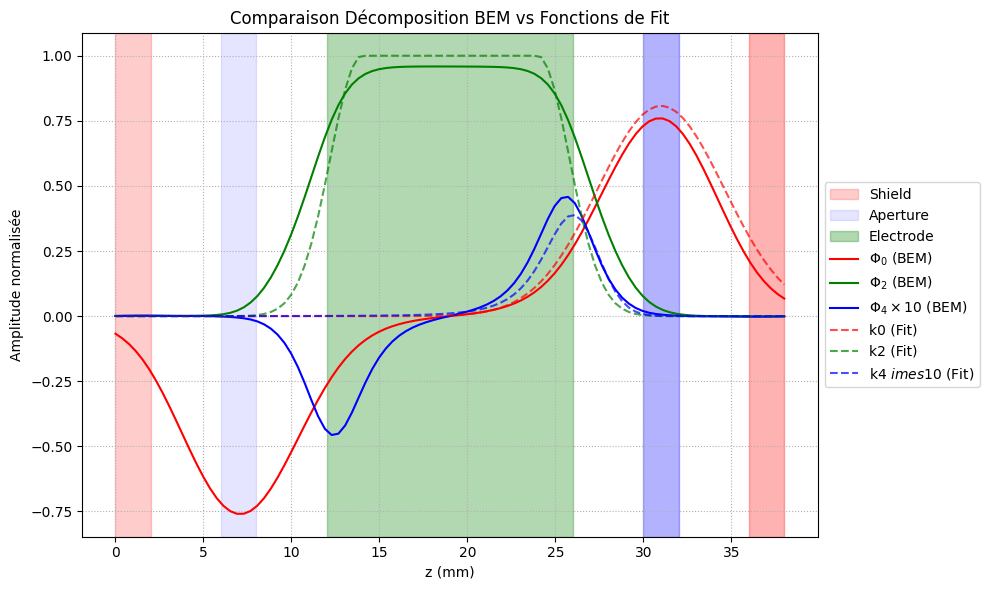

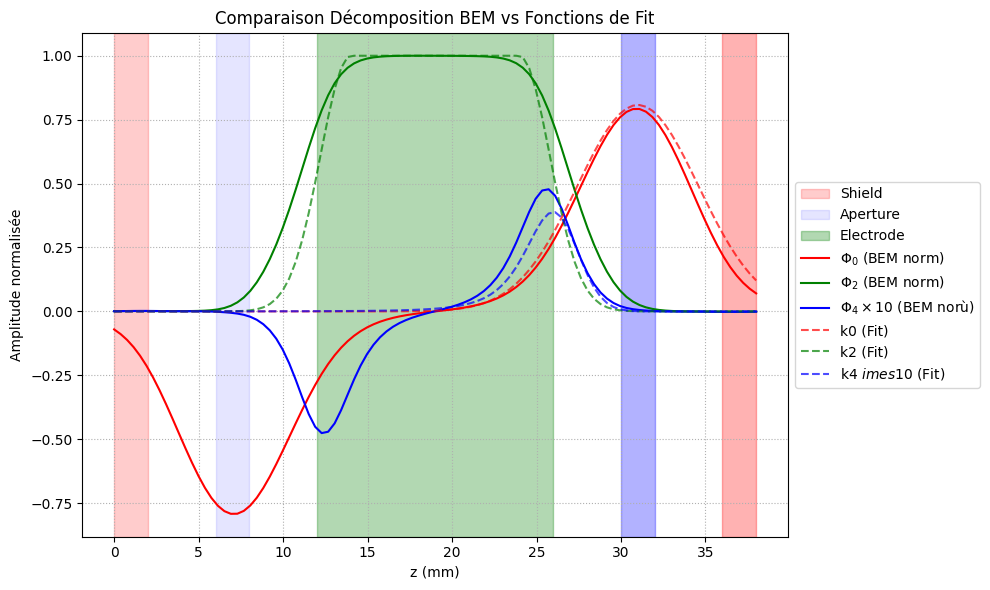

In [66]:
%load_ext autoreload
%autoreload 2

# 1. Définition du chemin du fichier sauvegardé
file_path =r"potentiel_quadrupole_VF.npz"

data = Extraction(file_path, pots, dims)

# 3. Calcul de la décomposition multipolaire (Phi0, Phi2, Phi4)
# Cette méthode extrait les dérivées et les normalise
data.derive()
data.decompose()
data.fit_functions()
data.normalisation()
data.plot_decomposition()
data.plot_normalisation()



Paraxial

20000
20000


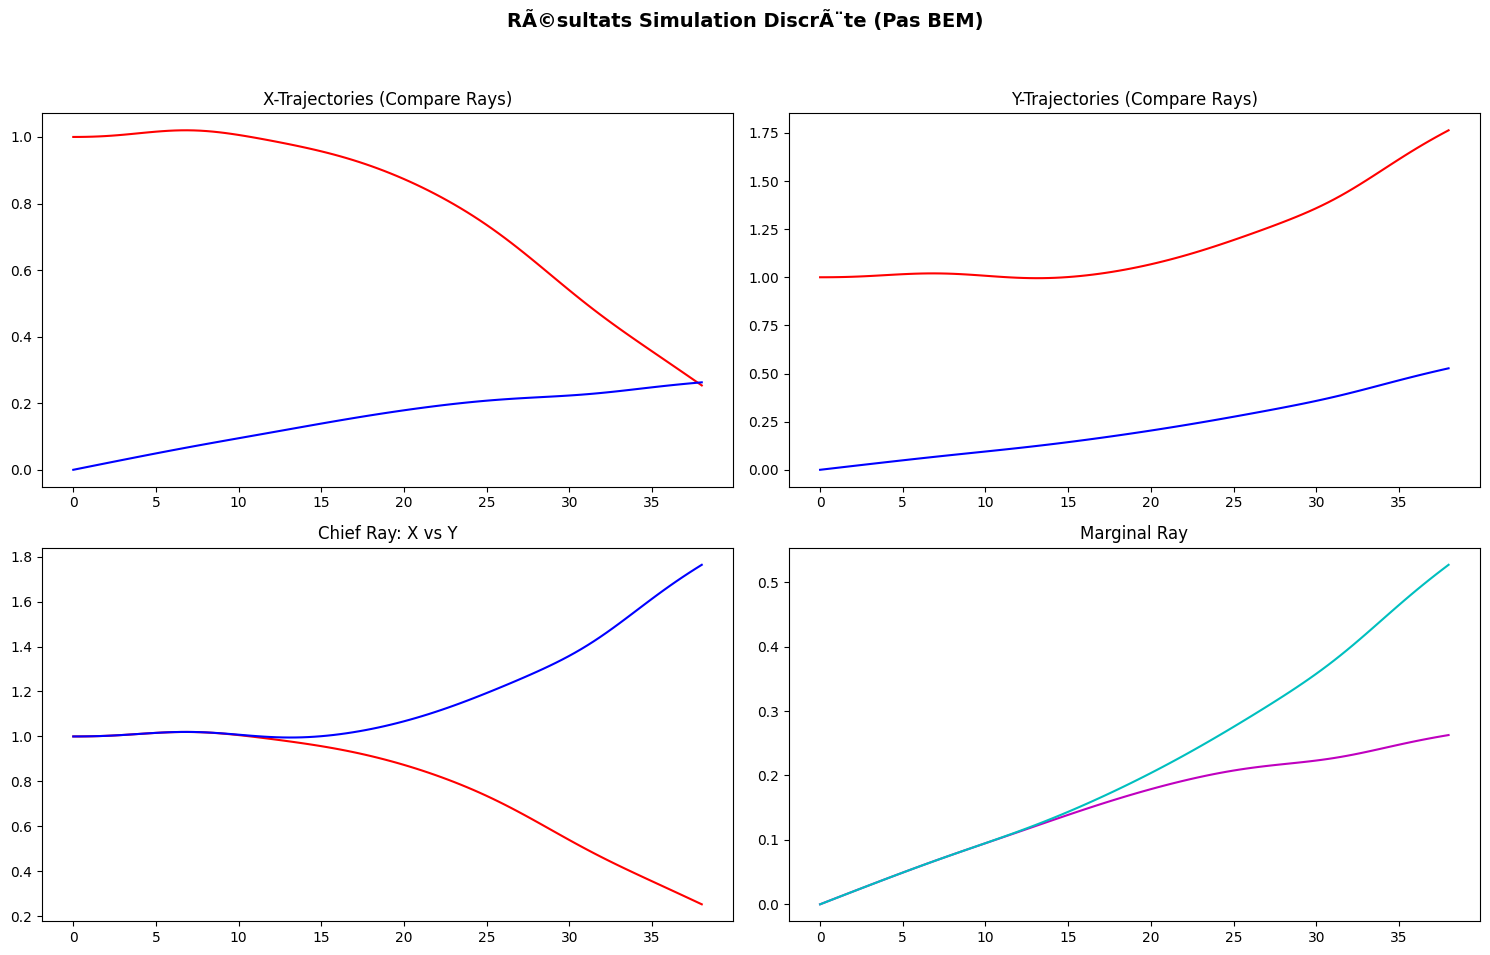

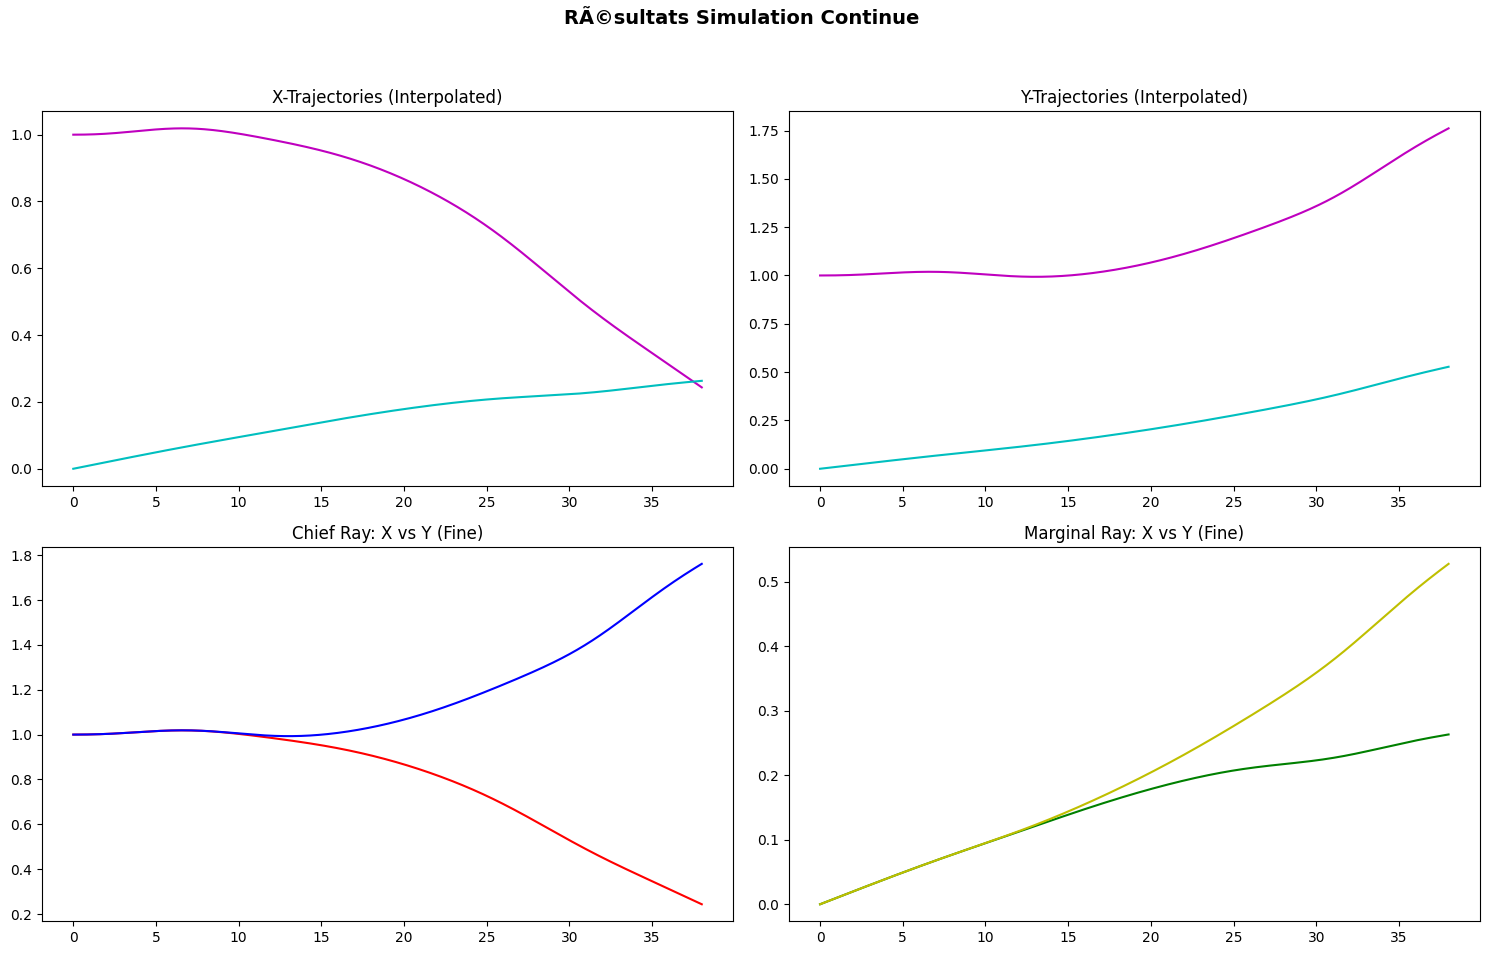

In [70]:
e = -1.6e-19
# 1. Initialisation
mon_moteur = Trajectoire(pots, dims)
convergence = Trajectoire(pots, dims)

# 2. Simulation Discrète
# Créer ions pour discret
marginal = Ion(1.6e-27, e, "principal", 0, 0.01, 0, 0.01, pots, dims)
principal = Ion(1.6e-27, e, "marginal", 1, 0, 1, 0, pots, dims)
mon_moteur.simulation3(marginal, data)
mon_moteur.simulation3(principal, data)
mon_moteur.plot_discret(principal, marginal, data)

# 3. Simulation Continue
# Créer ions pour continu
m_cont = Ion(1.6e-27, e, "p_cont", 0, 0.01, 0, 0.01, pots, dims)
p_cont = Ion(1.6e-27, e, "p_cont", 1, 0, 1, 0, pots, dims)
convergence.convergence(data, n=5) # 5 fois plus de points
convergence.simulationf(m_cont, data)
convergence.simulationf(p_cont, data)
convergence.plot_continu(p_cont, m_cont, data)